In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/ruch/Desktop/ML-Engineer/Core/Machine Learning/Data/10-diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [4]:
df.drop("Unnamed: 0", axis=1, inplace=True)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.describe()
# mean ve median (%50) bakarak aradaki farka göre outliers var mı kontrol et

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [7]:
df[df["x"] == 0]

,carat,cut,color,clarity,depth,table,price,x,y,z
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.0,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.00,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.00,0.0
24520,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.00,0.0
26243,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.00,0.0
27429,2.25,Premium,H,SI2,62.8,59.0,18034,0.0,0.00,0.0
49556,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0


In [8]:
len(df[df["x"] == 0]), len(df[df["y"] == 0]), len(df[df["z"] == 0])

(8, 7, 20)

In [9]:
df[df["x"] == 0].index

Index([11182, 11963, 15951, 24520, 26243, 27429, 49556, 49557], dtype='int64')

In [10]:
df.drop(df[df["x"] == 0].index, inplace=True, axis=0) # axis 0 satır siler
df.drop(df[df["y"] == 0].index, inplace=True, axis=0)
df.drop(df[df["z"] == 0].index, inplace=True, axis=0)

In [11]:
df.describe()

,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [12]:
len(df[df["x"] == 0]), len(df[df["y"] == 0]), len(df[df["z"] == 0])

(0, 0, 0)

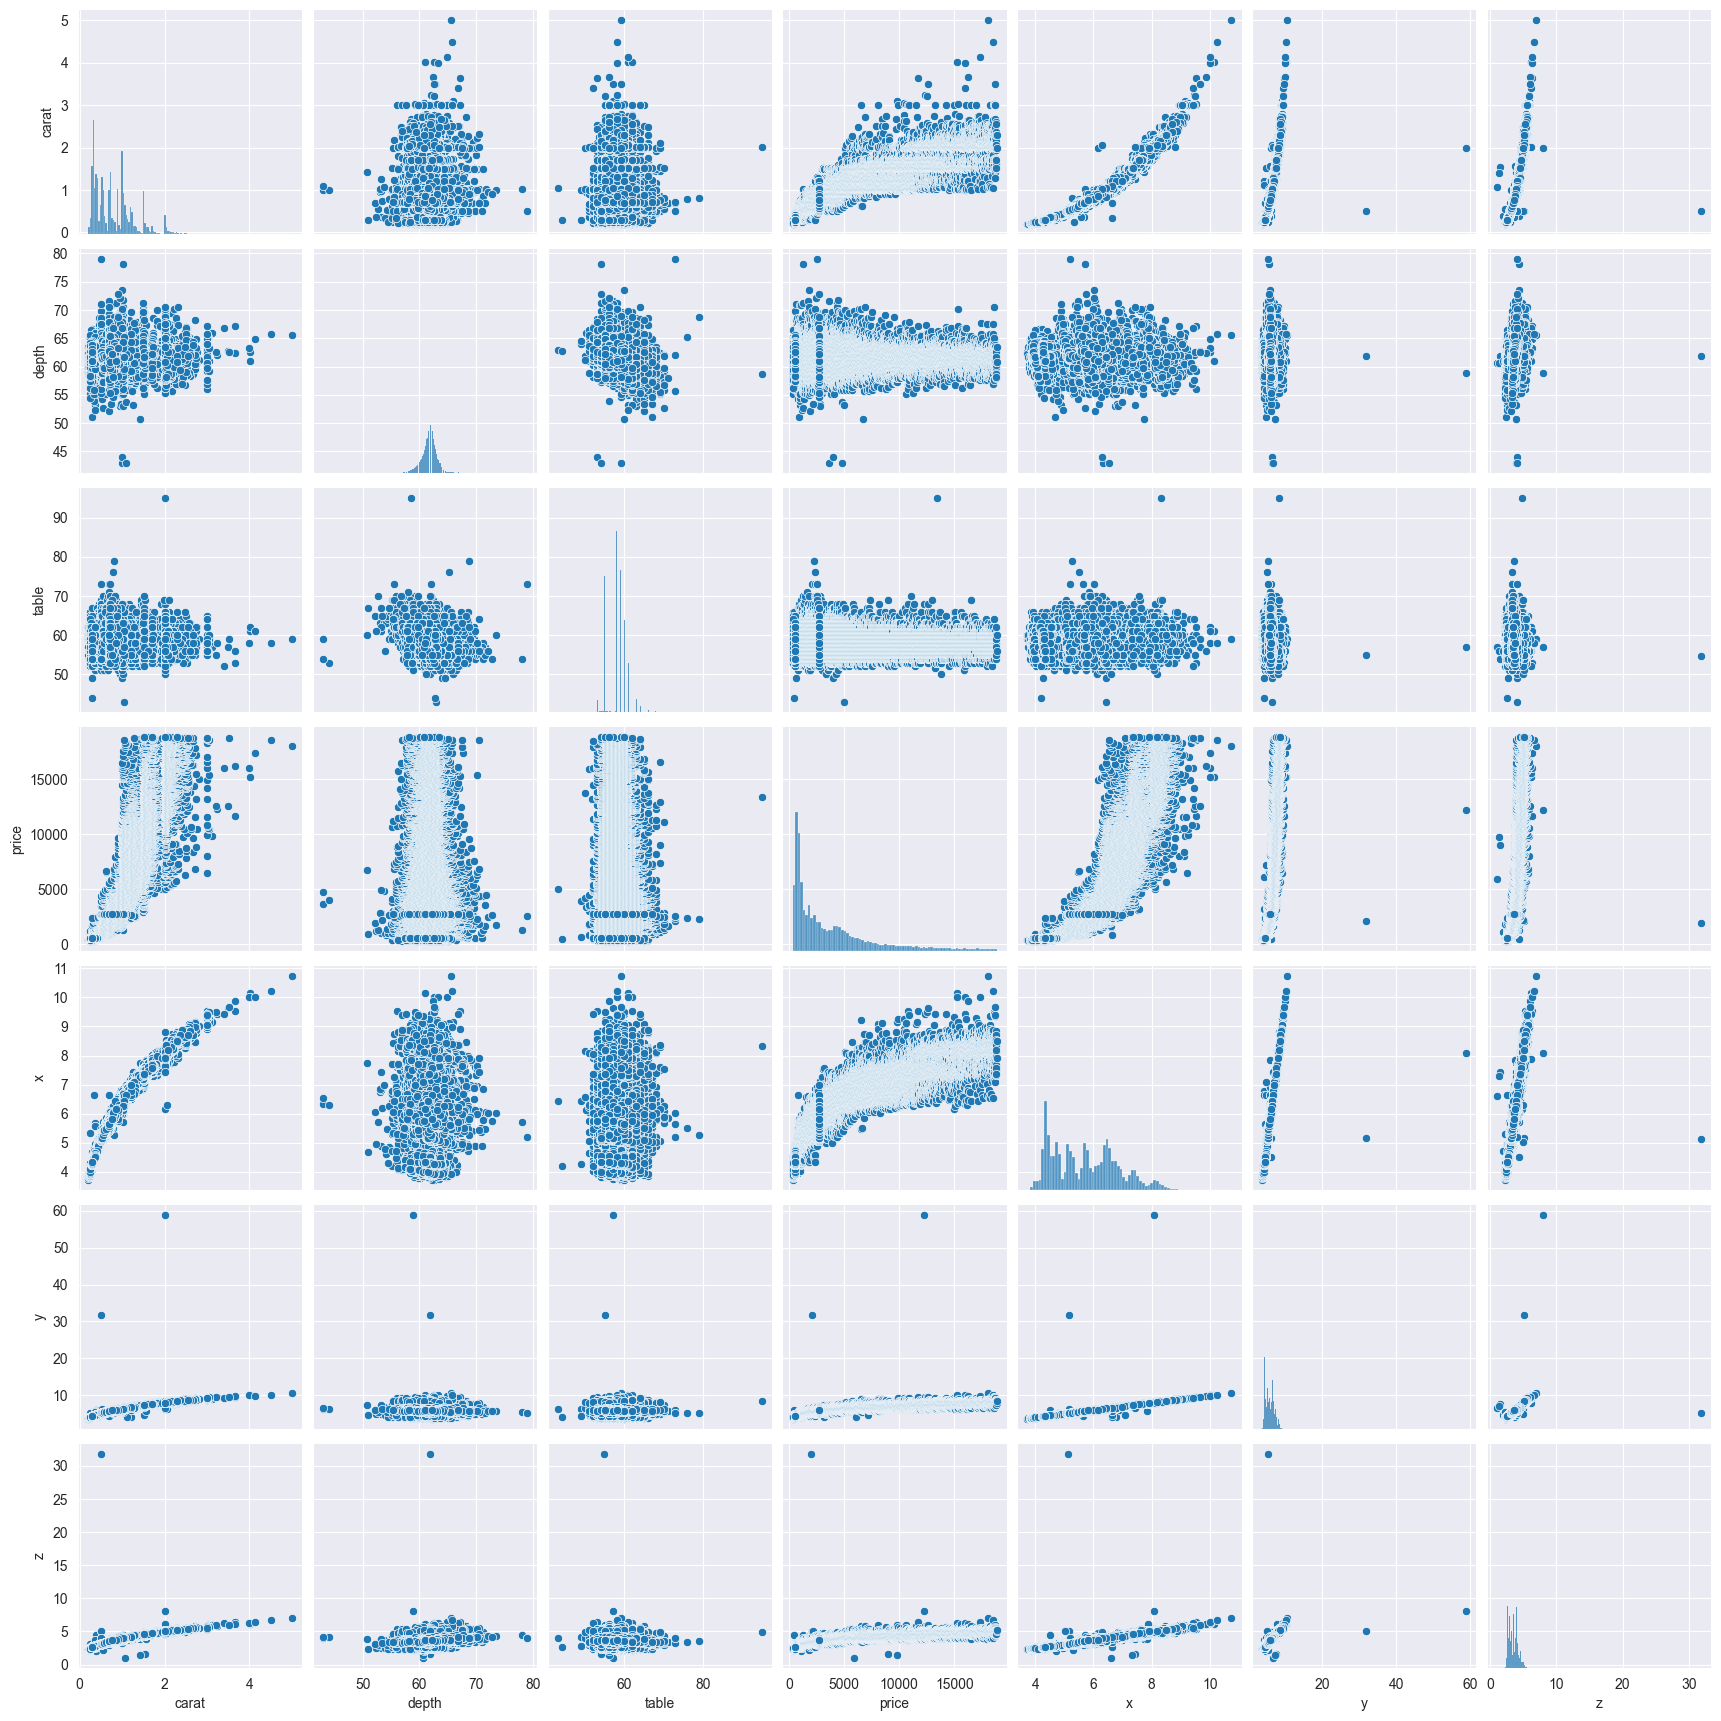

In [13]:
sns.pairplot(df)
plt.show()

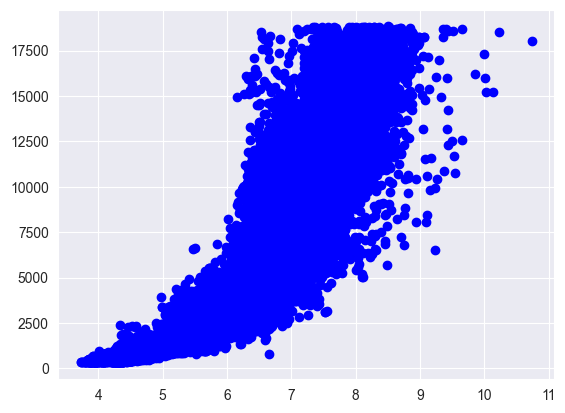

In [14]:
plt.scatter(data=df, x='x', y='price', color='blue')
plt.show()

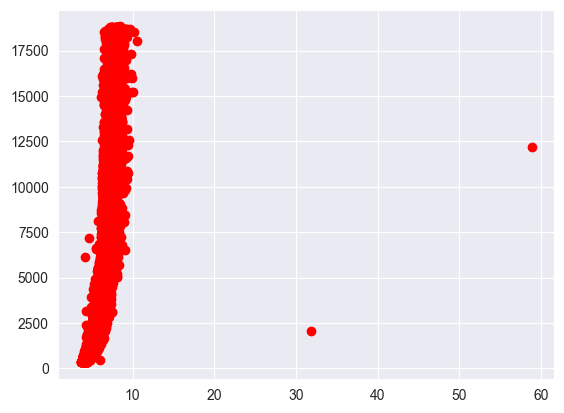

In [15]:
plt.scatter(data=df, x='y', y='price', color='red')
plt.show()

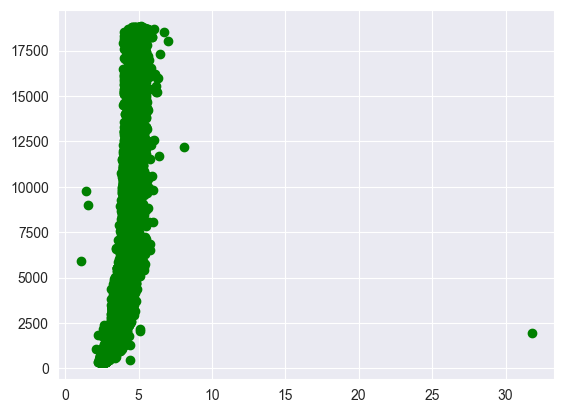

In [16]:
plt.scatter(data=df, x='z', y='price', color='green')
plt.show()

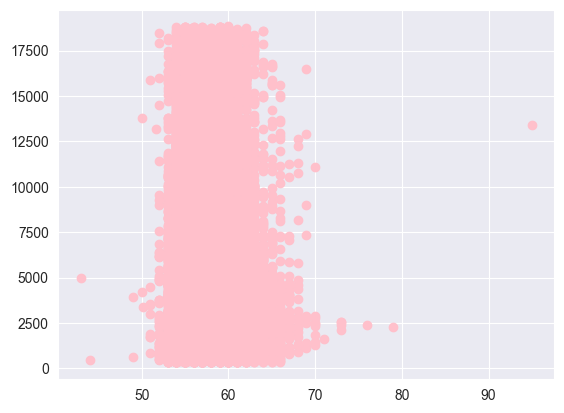

In [17]:
plt.scatter(data=df, x='table', y='price', color='pink')
plt.show()

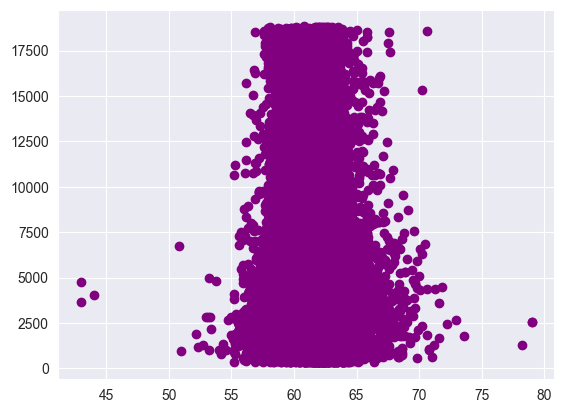

In [18]:
plt.scatter(data=df, x='depth', y='price', color='purple')
plt.show()

In [19]:
df[(df['depth'] < 75) & (df['depth'] > 45)]

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [20]:
df[(df['table'] < 75) & (df['table'] > 40)]

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [21]:
df[(df['z'] < 15) & (df['z'] > 2)]

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [22]:
df[(df['y'] < 20)]

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [23]:
df[(df['x'] < 10)]

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [24]:
df.describe()

,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [25]:
df = df[(df['depth'] < 75) & (df['depth'] > 45)]
df = df[(df['table'] < 75) & (df['table'] > 40)]
df = df[(df['z'] < 15) & (df['z'] > 2)]
df = df[(df['y'] < 20)]
df = df[(df['x'] < 10)]

In [26]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [27]:
df.describe()

,carat,depth,table,price,x,y,z
count,53899.000000,53899.000000,53899.000000,53899.000000,53899.000000,53899.000000,53899.000000
mean,0.797241,61.749314,57.454940,3929.220319,5.730979,5.732828,3.539117
std,0.472360,1.419535,2.222745,3985.179286,1.118472,1.110376,0.690784
min,0.200000,50.800000,43.000000,326.000000,3.730000,3.680000,2.060000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2400.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5321.000000,6.540000,6.540000,4.035000
max,3.670000,73.600000,73.000000,18823.000000,9.860000,9.810000,6.380000


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53899 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53899 non-null  float64
 1   cut      53899 non-null  object 
 2   color    53899 non-null  object 
 3   clarity  53899 non-null  object 
 4   depth    53899 non-null  float64
 5   table    53899 non-null  float64
 6   price    53899 non-null  int64  
 7   x        53899 non-null  float64
 8   y        53899 non-null  float64
 9   z        53899 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB


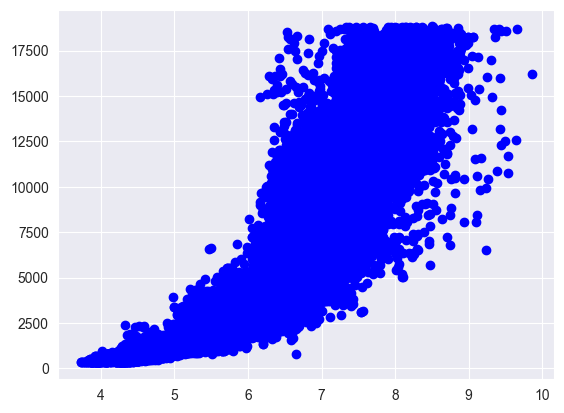

In [29]:
plt.scatter(data=df, x='x', y='price', color='blue')
plt.show()

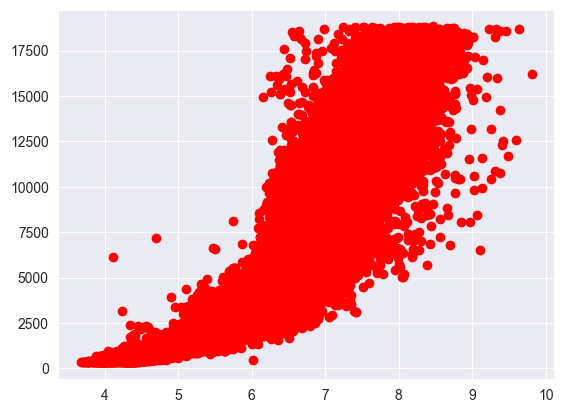

In [30]:
plt.scatter(data=df, x='y', y='price', color='red')
plt.show()

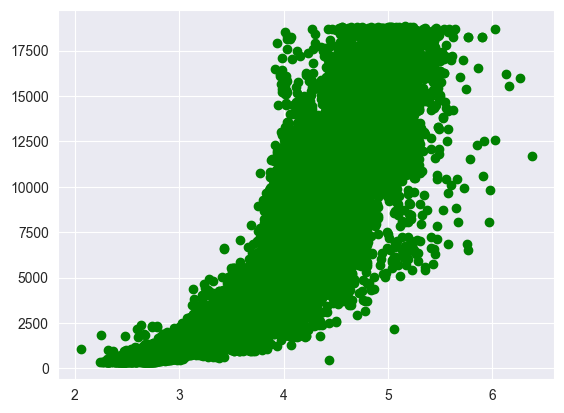

In [31]:
plt.scatter(data=df, x='z', y='price', color='green')
plt.show()

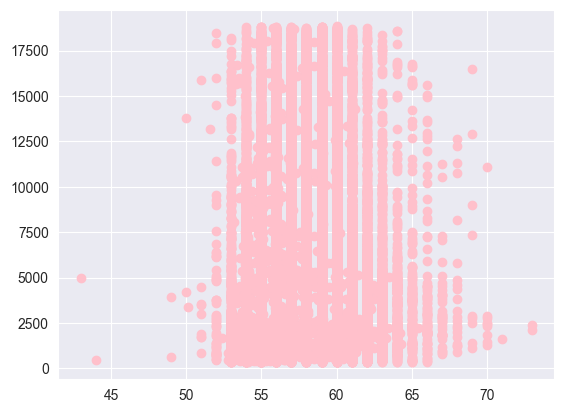

In [32]:
plt.scatter(data=df, x='table', y='price', color='pink')
plt.show()

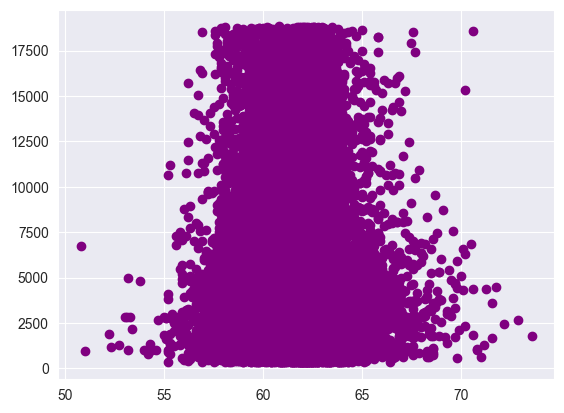

In [33]:
plt.scatter(data=df, x='depth', y='price', color='purple')
plt.show()

In [34]:
# Encoding
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [35]:
df["cut"].value_counts()

cut
Ideal        21543
Premium      13777
Very Good    12079
Good          4902
Fair          1598
Name: count, dtype: int64

In [36]:
df["color"].value_counts()

color
G    11281
E     9792
F     9535
H     8295
D     6774
I     5418
J     2804
Name: count, dtype: int64

In [37]:
df["clarity"].value_counts()

clarity
SI1     13058
VS2     12250
SI2      9183
VS1      8167
VVS2     5066
VVS1     3654
IF       1790
I1        731
Name: count, dtype: int64

In [38]:
X = df.drop("price", axis=1)
y = df["price"]

In [39]:
X

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,3.74


In [40]:
y

0         326
1         326
2         327
3         334
4         335
         ... 
53935    2757
53936    2757
53937    2757
53938    2757
53939    2757
Name: price, Length: 53899, dtype: int64

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [43]:
from sklearn.preprocessing import LabelEncoder

In [44]:
label_encoder = LabelEncoder()

In [45]:
for col in ['cut', 'color', 'clarity']:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_test[col] = label_encoder.transform(X_test[col])

In [46]:
X_train.head()

,carat,cut,color,clarity,depth,table,x,y,z
17450,1.01,4,2,4,62.8,58.0,6.32,6.39,3.99
36062,0.31,2,3,1,61.6,55.0,4.34,4.39,2.69
50687,0.54,2,3,1,61.5,55.0,5.24,5.30,3.23
43447,0.50,1,1,2,63.8,55.0,5.09,5.04,3.23
41698,0.45,1,1,4,61.7,63.0,4.88,4.91,3.02


In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error

In [50]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE: ", mae)
print("R2: ", r2)
print("MSE: ", mse)

MAE:  844.5131314755942
R2:  0.8850931328705874
MSE:  1745034.6249594563


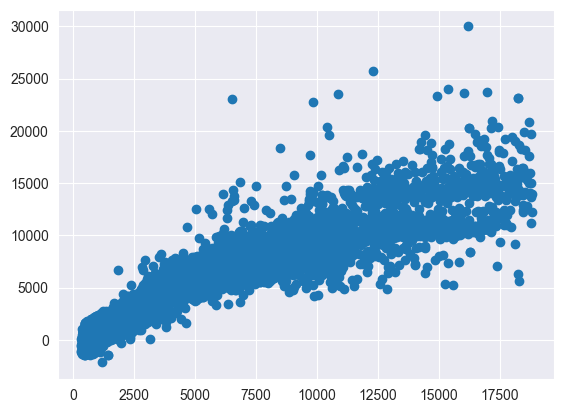

In [51]:
plt.scatter(y_test, y_pred)
plt.show()

In [52]:
from sklearn.svm import SVC, SVR

In [53]:
svr = SVR()
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE: ", mae)
print("R2: ", r2)
print("MSE: ", mse)

MAE:  1333.0916776884158
R2:  0.5152891138399149
MSE:  7361068.146532224


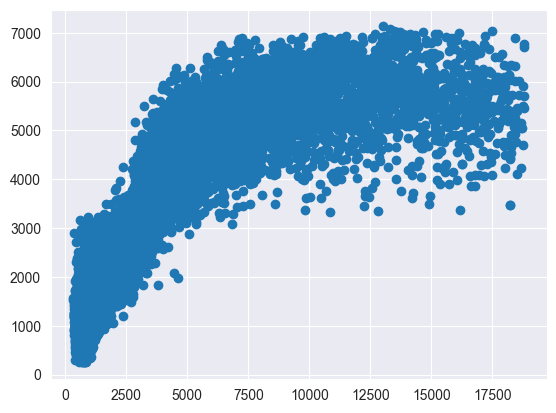

In [54]:
plt.scatter(y_test, y_pred)
plt.show()

In [55]:
# hyperparameter

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C" : [0.1, 1, 10, 100, 1000],
    "gamma" : [1, 0.1, 0.01, 0.001],
    "kernel" : ["linear", "rbf"],
}

In [ ]:
grid = GridSearchCV(estimator=SVR(), param_grid=param_grid, cv=5, n_jobs=-1, verbose=20)
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 3/5; 1/40] START C=0.1, gamma=1, kernel=linear..............................
[CV 1/5; 1/40] START C=0.1, gamma=1, kernel=linear..............................
[CV 2/5; 1/40] START C=0.1, gamma=1, kernel=linear..............................
[CV 1/5; 2/40] START C=0.1, gamma=1, kernel=rbf.................................
[CV 4/5; 1/40] START C=0.1, gamma=1, kernel=linear..............................
[CV 2/5; 2/40] START C=0.1, gamma=1, kernel=rbf.................................
[CV 5/5; 1/40] START C=0.1, gamma=1, kernel=linear..............................
[CV 3/5; 2/40] START C=0.1, gamma=1, kernel=rbf.................................
[CV 1/5; 3/40] START C=0.1, gamma=0.1, kernel=linear............................
[CV 4/5; 2/40] START C=0.1, gamma=1, kernel=rbf.................................
[CV 5/5; 2/40] START C=0.1, gamma=1, kernel=rbf.................................
[CV 1/5; 1/40] END C=0.1, gamma=1, kernel=linea

In [60]:
grid.best_params_

{'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}

MAE:  469.6680911646708
R2:  0.9431305454495209
MSE:  863648.7076214266


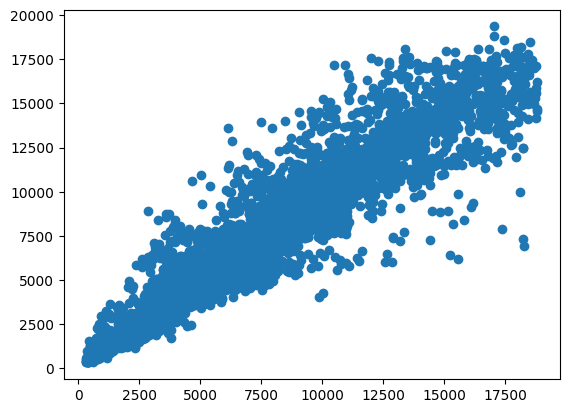

In [61]:
y_pred = grid.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE: ", mae)
print("R2: ", r2)
print("MSE: ", mse)

plt.scatter(y_test, y_pred)
plt.show()

In [ ]:
grid.best_score_